In [ ]:
# MIT License
#
# @title Copyright (c) 2021-2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Agricultural Monitoring with Fields of The World (FTW)

This tutorial demonstrates how to generate field boundaries globally using the Fields of The World dataset, pretrained models, and command line interface (CLI). You will then use those boundaries in agricultural monitoring tasks, including crop type classification and forest loss monitoring. See the [Learning Objectives](#learning-objectives) for what you will be able to do by the end.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Akramz/ccai-food-security-tutorial/blob/main/1.0-agriculture-monitoring-with-ftw.ipynb)

# Table of Contents

*   [Overview](#overview)
*   [Learning Objectives](#learning-objectives)
*   [Target Audience](#target-audience)
*   [Climate Impact](#climate-impact)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
*   [From Prototype to Practice](#prototype-to-practice)
*   [Final Discussion & Takeaways](#final-discussion-takeaways)
*   [Limitations & Responsible Use](#limitations)
*   [References](#references)
*   [Authors and Contact Information](#authors)

<a name="overview"></a>  
# 🌍 Overview  

This tutorial introduces participants to the [Fields of The World (FTW)](https://fieldsofthe.world/) ecosystem (benchmark dataset, pretrained segmentation models, and command-line interface) and demonstrates how it can be used to address pressing agricultural challenges under climate change. The tutorial’s main contribution is to show how users can generate field boundaries anywhere globally and then use these boundaries for downstream machine learning tasks in agricultural monitoring.

In plain terms, a *field boundary* is the outline of a single agricultural field. Drawing these outlines turns a raw satellite image into a set of per-field units you can measure, classify, and track over time. A field unit is the building block for almost all agricultural monitoring.

This matters for food security as much as for climate. FAO estimates that about 673 million people faced hunger in 2024 ([SOFI 2025](https://www.fao.org/publications/fao-flagship-publications/the-state-of-food-security-and-nutrition-in-the-world/en)). Reliable per-field crop maps are used in crop type mapping, yield forecasting, and early-warning systems that help governments and agencies anticipate shortages.

The goal of the tutorial is to give users hands-on experience with an end-to-end pipeline that links data, tools, and methods for climate-related agricultural monitoring 🔗. See the [Learning Objectives](#learning-objectives) for the specific skills you will build.

<a name="learning-objectives"></a>
# 🧭 Learning Objectives

By the end of this tutorial, you will be able to:

1. 📐 **Generate field boundaries** for any region of interest from Sentinel-2 imagery using the FTW model and CLI.
2. 🧩 **Understand how FTW works** - how to run a model to get field/boundary segmentation masks and how those raster predictions become vector field polygons.
3. 🌾 **Classify crop types from a few labels** using per-field embeddings, and read how accuracy changes as more labels are added.
4. 🌳 **Monitor forest loss** by joining boundaries with the Hansen Global Forest Change dataset.
5. ⚖️ **Judge when outputs are fit to act on** — recognizing boundary uncertainty, regional domain shift (accuracy dropping when the model meets fields unlike those it was trained on), and the need for local validation before any real decision.

<a name="target-audience"></a>
# 🎯 Target Audience

This tutorial is designed for **researchers, practitioners, and students working at the intersection of climate, agriculture, and machine learning**.

Specifically, it is intended for:  

* 🌱 **Climate and agricultural scientists** who may not have a strong background in machine learning but want to learn how modern geospatial AI tools can be applied to monitor crop production and forest loss under climate change.  
* 🤖 **Machine learning researchers and data scientists** with prior experience in deep learning or geospatial analysis who are seeking real-world, climate-relevant applications to test and adapt their methods.  
* 🏛️ **Policymakers, NGOs, and sustainability professionals** interested in understanding how field-scale monitoring tools can support compliance with sustainability standards (e.g., the EU Deforestation Regulation), improve food security planning, and inform conservation decisions.  
* 🎓 **Graduate students and early-career researchers** who want hands-on experience with open datasets, tools, and workflows that bridge technical machine learning methods with applied climate and agricultural challenges.  


<a name="climate-impact"></a>
# 🌎 Climate Impact

### Pathways to Positive Climate Impact  

Agriculture both drives and is affected by climate change. Agricultural expansion and poor land management contribute significantly to deforestation, biodiversity loss, and greenhouse gas emissions. On the other hand, climate change itself threatens crop yields, food security, and rural livelihoods. Accurate, up-to-date data about where fields are located and how they are being managed is essential for building sustainable and resilient food systems. However, this information is often unavailable, outdated, or fragmented in many parts of the world.  

This tutorial introduces the **Fields of The World (FTW)** machine learning ecosystem and demonstrates how it can be used to automatically generate field boundaries globally. These boundaries provide a foundation for downstream monitoring tasks like crop type classification and forest loss detection, which are critical for climate-related decision-making.  

#### Who will use these models and how?  
* 🌍 **Policymakers and regulators** (e.g., under the EU Deforestation Regulation, EUDR) can use field-level monitoring to verify compliance with deforestation-free supply chains. This ensures that commodities like soy, palm oil, and cocoa are not driving illegal forest loss.  
* 🌱 **NGOs, development organizations, and agencies** can use the models to track agricultural expansion and design interventions that protect vulnerable ecosystems while supporting farmers.  
* 🏭 **Private sector actors** (e.g., food companies, climate-tech startups, or Monitoring Reporting and Verification (MRV) service providers) can integrate field boundary datasets and models into supply chain monitoring systems, helping corporations meet sustainability pledges and reduce climate risk.  
* 👩‍🌾 **Farmers and cooperatives** can benefit indirectly through improved access to climate finance, climate-smart certifications, carbon markets, or targeted advisory services built on these monitoring tools.  

#### Real-world impact and decision pathways  
1. 🌾 **Crop type classification** models support yield forecasting, production estimation, and food security planning. Governments and international agencies can anticipate shortages and mobilize relief efforts earlier, reducing vulnerability to climate-driven shocks. In-season crop type maps enable rapid response assessments of damage to food production when disasters such as floods, fires, or tornadoes occur.  
2. 🌳 **Forest loss monitoring** within agricultural landscapes helps identify where land-use change is contributing to emissions and biodiversity loss. This informs land-use policy, conservation programs, and corporate sustainability audits and helps farmers/producers provide evidence for sustainable supply chain certifications.  
3. ⏱️ Combining these tools allows for **near-real-time, transparent monitoring** of agriculture and forest interactions at the field scale.  

#### System-level outcomes  
By equipping users with the ability to generate field boundaries and link them to climate-relevant monitoring tasks, this tutorial lowers the barrier for researchers, practitioners, and policymakers to access and deploy advanced geospatial AI.

The impact pathway extends from **technical outputs** (field boundaries, crop maps, forest loss detections) → to **actionable insights** (crop yield forecasts, deforestation alerts) → to **systemic changes** in agricultural management, supply chain governance, and climate adaptation strategies.

These methods have the potential to reduce emissions, protect ecosystems, and build resilience for farming communities worldwide.  

<a name="background-and-prereqs"></a>
# 📓 Background & Prerequisites

To get the most out of this tutorial, participants should have:  
* 🐍 **Basic Python programming skills** (variables, loops, functions, and libraries such as `numpy` and `pandas`).  
* 📓 Familiarity with **Jupyter notebooks** as an interactive environment for running code and exploring data.  
* 🤖 A general understanding of **machine learning** (e.g., training and evaluating models) and **geospatial data** (e.g., satellite imagery, vector vs. raster data) is helpful but not required.  

No prior experience with agricultural monitoring or the Fields of The World dataset is required.  

### Key Concepts  

To successfully follow the tutorial, users should be comfortable with the following concepts:  

* 🗺️ **Field boundaries**: Polygons that delineate agricultural fields on the Earth’s surface. They provide a spatial unit for monitoring and analysis, enabling crop type classification, yield prediction, and land-use change assessment.  
* 🛰️ **Remote sensing / Earth observations**: Data captured by satellites (e.g., Sentinel-2, Landsat) that provide multi-spectral views of Earth. Remote sensing allows large-scale, repeatable, and timely monitoring of agriculture and forests.  
* 🛰️ **Sentinel-2**: Free satellite imagery from the EU Copernicus programme, covering the entire land surface every ~5 days at 10 m resolution across many spectral **bands** (*multispectral* = capturing light beyond what the eye can see, e.g. near-infrared). Those extra bands make crops, water, and bare soil easy to tell apart — this is the imagery the FTW model reads.  
* 📐 **Vector vs. raster data**: Vector data (points, lines, polygons) represent discrete features such as field boundaries, while raster data represent gridded continuous surfaces such as satellite images or deforestation maps.  
* 🧩 **Segmentation mask**: The image output of a segmentation model — a per-pixel image where every pixel is tagged with a class (here: field *interior*, field *boundary*, or *background*). Converting these tagged pixels into polygons (*polygonizing*) is what turns the mask into vector field boundaries.  
* 🌾 **Crop type classification**: A machine learning task that assigns labels (e.g., maize, soy, wheat) to agricultural fields based on spectral and temporal information from satellite imagery. This supports food security planning and yield forecasting.  
* 🌳 **Forest loss monitoring**: The detection of deforestation events, often using global datasets (e.g., Hansen Global Forest Change). Linking these to field boundaries helps assess whether agricultural expansion is driving forest loss.  
* 🌍 **Climate relevance**: Agricultural monitoring contributes to climate change mitigation (reducing emissions from deforestation, promoting sustainable practices) and adaptation (anticipating crop failures, ensuring food security).  

<a name="software-requirements"></a>
# 💻 Software Requirements

This notebook requires Python (>= 3.11 and < 3.13) and an environment to run Jupyter notebooks.

All requirements can be installed through `pip` by running:
```bash
pip install -r requirements.txt
```

If you are using Conda, we provide a lightweight environment file `env.yml` (that simply wraps the `requirements.txt` dependencies). You can install it by running:
```bash
# Install environment
conda env create -f env.yml
# Activate environment
conda activate ftw-tutorial
```

<!--

All tutorial submissions must have a separate `requirements.txt` file stating all dependencies and versions for software, packages, or tooling used in the tutorial. This file allows tutorial users who would like to run a copy of the notebook locally with all dependencies needed to create their own virtual environment/IPython kernel.

In bash you may create a `requirements.txt` by typing the following command:

`pip freeze > requirements.txt'

Avoid undocumented dependencies.

We encourage explicitly printing out your dependencies using a notebook extension such as [watermark](https://github.com/rasbt/watermark) at the bottom of your notebook.

Within the notebook, there must be a cell which includes the necessary directory structure to retrieve files or data using relative paths for ease of use. If data is private, please provide a similar public sample for those that would like to reproduce or extend your work. Instructions and imports with versioning must be provided and clearly labeled at the top.

Document the beginning and end date of your analysis to contextualize the development stage of the notebook in the event that highlighted packages or content is updated in the future.
-->

In [ ]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = (
    "TRUE"  # when multiple copies of OpenMP are found we get a warning, this silences it
)

# If you have GDAL installed in your environment, these environment variables can cause issues
# with rasterio and fiona. So we unset them here.
for entry in ["GDAL_DATA", "PROJ_NETWORK", "PROJ_DATA", "GDAL_DRIVER_PATH"]:
    if entry in os.environ:
        del os.environ[entry]

# If the notebook was opened in Colab then clone this repo and install required packages
if "google.colab" in str(get_ipython()):
    if not os.path.exists("ccai-food-security-tutorial"):
        !git clone https://github.com/Akramz/ccai-food-security-tutorial.git
    os.chdir("ccai-food-security-tutorial")

    !pip install -r requirements.txt

In [ ]:
import utils
import leafmap
import geopandas as gpd
import pandas as pd
import rasterio
import torch

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mgrs import MGRS
from shapely.geometry import Point
from typing import List, Tuple
import matplotlib as mpl
from codecarbon import EmissionsTracker  # measures energy + CO2 of the heavy cells

### ⚙️ Run configuration (fast mode)

This tutorial defaults to **fast mode**: it uses smaller sample data and a lighter workload so the whole notebook runs well under the **2-hour** budget. **The method does not change** — only the amount of data and computation does. For a full, production-style run, set `fast_mode = False` below.

> ℹ️ `utils.download_and_run(...)` reuses an existing `ftw_boundaries_*.gpkg` if one is present, so on a **local re-run** a changed `buffer` won't take effect until you delete the stale boundary file. A fresh Colab session has nothing to reuse.

In [ ]:
CONFIG = {
    "fast_mode": True,          # master switch — set False for a full, "serious" run
    "buffer": 0.1,             # ROI half-width in degrees (0.1 -> 0.2° bbox)
    "cdl_source": "sample",    # "sample" = small bundled data; "full" = large download
    "lc_seeds": 3,             # learning-curve seeds (full run uses 10)
    "lc_fractions": [0.05, 0.1, 0.3, 0.5],  # label-budget grid (full run uses 7 points)
}
if not CONFIG["fast_mode"]:
    CONFIG.update(
        cdl_source="full",
        lc_seeds=10,
        lc_fractions=[0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    )

<a name="data-description"></a>
# 🗂️ Data Description

FTW uses a [semantic segmentation](https://huggingface.co/docs/transformers/en/tasks/semantic_segmentation) model to predict where agricultural fields and their boundaries are in [Sentinel-2](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-2) satellite images, which are then polygonized into individual objects (i.e., the raster predictions are turned into vector polygons). You can read more about the model and how it was trained in [Kerner et al. (2025)](https://arxiv.org/abs/2409.16252).

The FTW command line interface (CLI) makes it easy to get the data needed to run the FTW model and prepare field boundary polygons for downstream use cases. In this section, we'll teach you how to create field boundaries for anywhere in the world!

## 🗺️ The FTW workflow at a glance

Before diving into each step, here is the whole pipeline end to end — every stage below has a matching code section later in the notebook:

1. **Inputs — two Sentinel-2 scenes.** FTW looks at the same place at two moments in the growing season ("Window A" near the start, "Window B" near the end). The contrast between an early and a late view makes field edges stand out. The two dates come from a crop calendar (next section).
2. **FTW model — segmentation.** A pretrained model turns the stacked imagery into a **per-pixel 3-class map**: *background*, *field boundary*, and *field interior*. The separate "boundary" class is the key trick — it keeps two touching fields from merging into one blob.
3. **Filter by land cover.** Predictions that fall outside cropland (e.g. pasture mistaken for a field) are removed using a land-cover map.
4. **Polygonize.** The cleaned raster becomes vector **field polygons** (a `.gpkg` file): connected interior pixels form one polygon, split apart along the predicted boundaries.
5. **Use the boundaries.** The polygons feed two downstream use cases — **crop-type mapping** (here: Iowa, USA) and **forest-loss monitoring** (Brazil).

In short: **two-date imagery → 3-class segmentation → land-cover filter → polygons → downstream monitoring.** The diagram below shows the same flow.

<img alt="FTW pipeline: two Sentinel-2 windows (A near start, B near end of season) feed the FTW model's 3-class segmentation (background / boundary / interior); the result is filtered by land cover and polygonized into field polygons (.gpkg), which feed two use cases — crop-type mapping (MOSAIKS + CDL) and forest-loss monitoring (Hansen / GLAD)." src="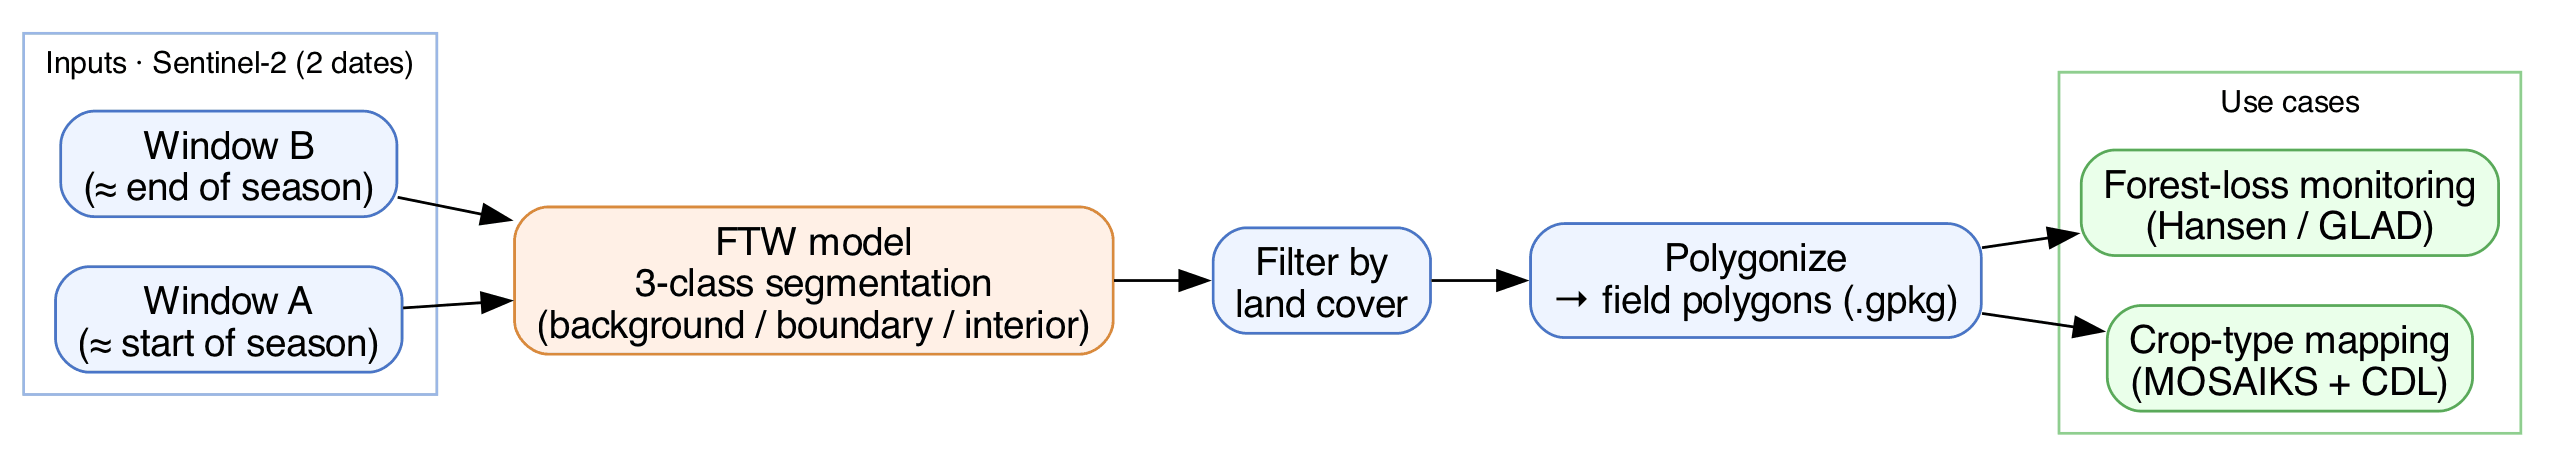" style="max-width:100%;">

<sub>Two Sentinel-2 windows → FTW 3-class segmentation → filter by land cover → polygonize → crop-type &amp; forest-loss use cases.</sub>

### 📚 The data at a glance

This tutorial pulls together several open datasets. Here is each one and its job:

| Dataset | Role in this tutorial | Source |
|---|---|---|
| Sentinel-2 L2A (Windows A & B) | Model input: two dated, low-cloud scenes (8 bands = 2 × RGB+NIR) | Microsoft Planetary Computer |
| Crop calendars (start / end of season) | Pick the two window dates for a location & season | ESA WorldCereal |
| Land-cover map | Remove non-cropland false positives after segmentation | Impact Observatory (default) / ESA WorldCover |
| USDA Cropland Data Layer (CDL) | Crop-type **labels** (majority class inside each field) — crop use case | USDA NASS (via TorchGeo) |
| Hansen / GLAD Global Forest Change (`lossyear`) | Year of forest loss inside each field — forest use case | UMD / Google |

The first three feed the **boundary pipeline**; CDL and Hansen/GLAD are used only in the two **downstream use cases**.

**Analysis provenance.** Concrete regions and dates are set per use case: the crop-type example uses MGRS tile **14TPN (Iowa, USA), 2023 summer**, and the forest-loss example uses **21LXF (Brazil), 2022 winter**. Reference layers are **USDA CDL 2023** and **Hansen/GLAD Global Forest Change GFC-2024-v1.12** (loss years 2001–2024). The two Sentinel-2 window dates are derived at run time from the ESA WorldCereal crop calendar (≈ ±15 days around season start, and the final 30 days before season end), so exact acquisition dates depend on scene availability when you run the notebook.

## ⬇️ Data Download

The next few steps assemble the model's input: pick *where* (an MGRS tile), pick *when* (a year and season), turn the season into two image windows, and fetch the best Sentinel-2 scene for each window.

> ⚖️ **Responsible use — inputs.** This step is meant to *support* fast, reproducible imagery selection for a demo — not to guarantee a clean observation. The scene search escalates its cloud filter up to **100% cover** and keeps a single snapshot per window (no cloud-free compositing), so a "best" scene can still be hazy or partly clouded. Inspect the previews before trusting anything downstream, and treat persistently cloudy regions (e.g., humid tropics) as lower-confidence.

### 📍 Specify your region of interest (ROI)
Sentinel-2 data uses the MGRS (Military Grid Reference System) tiling system, meaning Sentinel-2 observations are organized by their MGRS Tile ID. This makes the MGRS Tile ID a convenient way to specify an ROI for FTW models that use Sentinel-2 inputs.

In the cell below, you can select or specify the MGRS Tile ID.

In [ ]:
# Either manually set a MGRS tile id here or select one on the map
tile_id = "14TPN"
utils.pick_mgrs_tile(tile_id)

In [ ]:
tile_id = utils.get_selected_tile_id()
print(f"Selected tile ID: {tile_id}")

### ⏰ Specify your time of interest (TOI)

Field boundaries at the same location may change from year to year due to the dynamic nature of crop cultivation and land cover/land use change globally. Many regions have multiple growing seasons too (e.g., summer or winter).

In the cell below, you will specify the year, and season to run FTW.

In [ ]:
year = 2023

# Choose winter or summer season
# season = "winter"
season = "summer"

One MGRS tile covers a very large area: 100 km x 100 km. This can take a while to download and process, so to speed up computation for this tutorial, we'll restrict our ROI to a relatively small area (about 0.2° × 0.2°, using a 0.1° buffer around the tile center) in the center of the specified MGRS tile.

In [ ]:
lat, lon = MGRS().toLatLon(
    tile_id + "5000050000"
)  # This gets the center of the MGRS tile
tile_center = Point(lon, lat)

# Only download the imagery in a relatively small window around the tile center to speed up processing
buffer = CONFIG["buffer"]
bbox_string = f"{lon - buffer},{lat - buffer},{lon + buffer},{lat + buffer}"

### 🗓️ Get the start and end of season dates from crop calendar

FTW uses Sentinel-2 images from the beginning and end of an agricultural season to identify boundaries (called "Window A" and "Window B"). Since crop growth is changing between these two times, the contrasting views of the scenes help identify which parcels are agricultural (as opposed to other, less dynamic land cover types like grassland) and delineate the boundaries between fields that might not be obvious in a single scene.

[Crop calendars](https://ipad.fas.usda.gov/ogamaps/cropcalendar.aspx) specify when different crop cultivation stages are happening for a given location and season. In this tutorial, we'll use the [global crop calendars from the ESA WorldCereal project](https://github.com/ucg-uv/research_products/) to define our two windows.

In [ ]:
utils.download_crop_calendars()

start_tif = utils.crop_calendar_files[season]["start"]
end_tif = utils.crop_calendar_files[season]["end"]

start_date, end_date = utils.get_dates_from_tifs(
    point=tile_center,
    start_season_tif_path=start_tif,
    end_season_tif_path=end_tif,
    year=year,
    season_type=season,
)

print(f"Season start date: {start_date}")
print(f"Season end date: {end_date}")

From the season's start and end dates we derive the two image windows: **Window A** brackets the start of the season (a ±15-day span) and **Window B** covers the last month before the end of season (its final 30 days). Comparing an early-season and a late-season view is exactly what lets the model tell cropland apart from land cover that changes little over the season.

In [ ]:
win_a_start, win_a_end, win_b_start, win_b_end = utils.calculate_window_dates(
    start_date, end_date
)

print(f"Window A start date: {win_a_start}")
print(f"Window A end date: {win_a_end}")
print(f"Window B start date: {win_b_start}")
print(f"Window B end date: {win_b_end}")

### 🪟 Download Sentinel-2 images for Window A and Window B

Next, we need to select which Sentinel-2 images we'll use within each Window. The cell below searches for the best (least cloudy, most valid data) images within each window in the Sentinel-2 data catalog.

In [ ]:
# Requesting the STAC Items for the best images
win_a, win_b = utils.get_best_images(
    win_a_start, win_a_end, win_b_start, win_b_end, s2_tile_id=tile_id
)

Here's a preview of the selected images:

In [ ]:
utils.show_previews(win_a, win_b)

After finding the two Sentinel-2 scenes to use, we can download them and assemble them in FTW input format using the FTW CLI. The input format to FTW models contains the two 4-band (red, green, blue, near-infrared) images stacked together. This gives us an 8-band TIF raster.

Warning: When running the cell below, you may get the error `"Processing version of imagery differs. Exiting."` This is a known issue with the Planetary Computer catalog search that is being fixed in an upcoming release of the `ftw-tools` package. We will update the tutorial when this is fixed. If you get this error, try picking a different tile or earlier year.

In [ ]:
image_filename = f"ftw_input_{tile_id}_{season}_{year}.tif"

!ftw inference download --win_a {win_a.id} --win_b {win_b.id} --out {image_filename} --overwrite --bbox {bbox_string}

## 🛰️ Predict field boundaries

Now that we have our input imagery, we use a pretrained FTW model to segment it. The model outputs a **per-pixel 3-class map — *background*, field *boundary*, and field *interior*** — and that explicit boundary class is what stops two adjacent fields from being merged into a single polygon later on.

FTW provides [multiple pretrained models](https://github.com/fieldsoftheworld/ftw-baselines/releases) depending on your needs. For example, if your use case is commercial and you want to avoid models trained on non-commercial data, you can pick a version pretrained only on open (CC-BY) datasets.

Here we'll use the standard model trained on all datasets in the benchmark — the 3-class `THREE_CLASS_FULL` checkpoint.

> ⚖️ **Responsible use — boundaries.** These polygons *support* rapid, low-cost mapping of *where cropland likely is* — they are **not** cadastral, legal, or ownership boundaries, and should never on their own settle land tenure, allocate subsidies, or enforce compliance. Errors fall hardest on smallholders, whose small or irregular plots are the most likely to be merged or missed. Before acting, validate against local **ground truth** (independently verified reference data, e.g. field surveys or trusted maps) or high-resolution imagery — we quantify this next in *How good are these boundaries?*, and summarize every caveat under [Limitations & Responsible Use](#limitations).

In [ ]:
# Download the model checkpoint
model_filename = "3_Class_FULL_FTW_Pretrained.ckpt"

!ftw model download --type THREE_CLASS_FULL -o {model_filename}

> 📄 **Dataset & model documentation.** Before relying on these outputs, review how the training data was built and licensed in the [FTW datasheet](https://github.com/Akramz/ccai-food-security-tutorial/blob/main/deliverables/datasheet.md) (Gebru et al. format), and what this model can and can't do — intended use, metrics, and caveats — in the [model card](https://github.com/Akramz/ccai-food-security-tutorial/blob/main/deliverables/model_card.md) (Mitchell et al. format).

Next we use the pretrained model to predict the boundaries for our Sentinel-2 input.

If you are running this notebook on a machine that has a GPU, you can add `--gpu 0` to speed up computation. Also, you can add the flag `--mps_mode` if you're running on a Mac that has a GPU.

> ⚡ **Energy & emissions.** We wrap the two compute-heavy steps — this boundary inference and the embedding step later — in CodeCarbon's `EmissionsTracker` to report how much electricity (Wh) and CO₂ (g) running the AI costs. The figures are **estimates**: they depend on your hardware (GPU vs CPU) and on the carbon intensity of the local electricity grid, so they'll differ between Colab and your laptop.

In [ ]:
## Measure the energy + CO2 of running the boundary model (see the ⚡ note above).
tracker = EmissionsTracker(measure_power_secs=10, log_level="error", save_to_file=False)
tracker.start()

output_filename = f"ftw_predictions_{tile_id}_{season}_{year}.tif"

if torch.backends.mps.is_available():  # Check that MPS is available
    print("Running inference with MPS mode enabled")
    !ftw inference run {image_filename} --out {output_filename} --gpu 0 --mps_mode --model {model_filename} --overwrite
elif torch.cuda.is_available():  # check if GPU available
    print("Running inference with GPU enabled")
    !ftw inference run {image_filename} --out {output_filename} --gpu 0 --model {model_filename} --overwrite
else:  # use CPU mode
    print("Running inference with CPU only mode")
    !ftw inference run {image_filename} --out {output_filename} --model {model_filename} --overwrite

emissions = tracker.stop()
d = tracker.final_emissions_data
if d is not None:
    print(f"⚡ boundary inference: {d.energy_consumed*1000:.1f} Wh · "
          f"🌍 {(emissions or 0)*1000:.2f} g CO₂eq · ⏱ {d.duration:.0f}s")

### 🏠 Filter predicted by land cover
FTW models are known to make some comission errors, segmenting non-crop land cover (like pasture) as "fields". We can try to filter out some of these erroneous predictions using an existing land cover map.

This function uses the Impact Observatory landcover map by default, but you can also use ESA WorldCover by setting the `--collection_name` argument. If you'd like to see the cropland mask from the land cover map that's being used by the FTW CLI to filter the polygons, you can set the `--save_lulc_tif` flag.


In [ ]:
!ftw inference filter-by-lulc --help

In [ ]:
filtered_output_filename = f"ftw_predictions_filtered_{tile_id}_{season}_{year}.tif"

!ftw inference filter-by-lulc {output_filename} --out {filtered_output_filename} --overwrite

### 🟫 Polygonize boundaries

The final step is to convert the (raster-format) predictions of where the field boundaries are to the (vector-format) field boundary polygons.

Here are some additional options you can use when polygonizing boundaries, such as simplifying the geometries, filtering out minimum/maximum size, or removing holes within polygons.

In [ ]:
!ftw inference polygonize --help

In [ ]:
boundaries_filename = f"ftw_boundaries_{tile_id}_{season}_{year}.gpkg"

# Make sure to change {filtered_output_filename} to {output_filename}
# if you skipped the land cover filtering step
!ftw inference polygonize {filtered_output_filename} --out {boundaries_filename} -f

In [ ]:
field_boundaries = gpd.read_file(boundaries_filename)
print(f"Number of field boundaries: {len(field_boundaries)}")

### ✅ Checkpoint

In one sentence: what did the **polygonize** step take as input, and what did it produce?

<details><summary>Answer</summary> It took the filtered per-pixel boundary raster and turned it into vector field polygons — a `.gpkg` you can measure and join to other data. </details>

### 🧩 Convenience function

We've wrapped all of the above steps into a convenience function called `download_and_run` in the `utils.py` file that we will use for the rest of the tutorial. You can use this function to generate field boundaries for any MGRS tile, season, and year.


### 🗺️ Visualize the final field boundaries

Now that we've finished creating our field boundary polygon dataset, we can visualize them on the map to see how they look!

In [ ]:
if "google.colab" in str(get_ipython()):
    from google.colab import output

    output.enable_custom_widget_manager()

GOOGLE_MAPS_XYZ = "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"

m = leafmap.Map(
    center=[lat, lon],
    zoom=12,
    draw_control=False,
    measure_control=False,
    fullscreen_control=False,
    attribution_control=True,
)
m.add_tile_layer(url=GOOGLE_MAPS_XYZ, name="Google Satellite", attribution="Google")
m.add_geojson(field_boundaries, layer_name="Generated Fields")
m

### 🧪 How good are these boundaries?

We just generated polygons but never checked them against ground truth — so how is boundary quality actually judged?

- **On the FTW benchmark**, [Kerner et al. (2025)](https://arxiv.org/abs/2409.16252) score the model with **pixel-level IoU** (*Intersection over Union* — the area where the predicted field and the real field overlap, divided by the area they cover together; 0 = no overlap, 1 = a perfect match), **precision** (of the pixels the model labeled *field*, how many really are field), and **recall** (of the pixels that really are field, how many the model found), plus **object-level precision and recall** (a predicted field counts only if it overlaps a real field by IoU ≥ 0.5). Pixel-level IoU is fairly strong but varies by region — roughly **0.59 in Slovenia up to 0.79 in France and South Africa** — while **object-level** scores are much lower (precision/recall ≈ **0.2–0.6**). That gap is the honest headline: the model finds *cropland* well, but drawing each *individual field* correctly is harder. Accuracy also drops in regions underrepresented in training — a phenomenon called **domain shift** (*zero-shot* — tested on a region with no local training labels — pixel IoU falls to ≈ **0.43** on a held-out Cambodia/Vietnam split).
- **For your own ROI**, there is no ground-truth field map, so we can't compute those numbers here. The practical check is **qualitative**: overlay the polygons on high-resolution imagery (the map above) and look for over-merged fields, missed small parcels, or boundaries that slice through a single field. Treat the output as a strong starting point to validate locally — not as ground truth.

### 🧭 Is this output good enough to act on?

You now have field polygons for a region with **no local ground truth**. Match the output to the decision:

- **Lower-stakes, reversible** (e.g., choosing which villages to visit for a field survey): the polygons are a strong starting point even with some errors.
- **Higher-stakes, hard to reverse** (e.g., an EUDR non-compliance penalty, a subsidy decision, an official statistic): object-level accuracy is much lower than pixel accuracy, and accuracy drops in regions unlike the training data — so these need **local validation** first.

Ask yourself: *what is the cost of a wrong boundary here, and who bears it?* Write down one decision these boundaries could support today, and one they could not without more validation.

<a name="methodology"></a>
# ⚙ Methodology

In this section, we will demonstrate how to use FTW field boundaries in two different use cases of agricultural monitoring under climate change:  
1. 🌾 Crop type mapping in Iowa, United States  
2. 🌳 Forest loss monitoring in Brazil  

## 🌾 Use case: crop type mapping with few labels

Crop type mapping involves classifying agricultural fields into categories such as maize, wheat, soy, or rice, usually using satellite imagery and machine learning. A key challenge is that ground truth labels (farmer surveys, government records, or field visits) are scarce, expensive to collect, and unevenly distributed across the globe. This is especially true in regions where data infrastructure is weak but where climate change impacts on agriculture are most severe (e.g., Sub-Saharan Africa, parts of South Asia, Amazonia).

Few-label or weakly supervised methods allow us to train crop classification models using very limited labeled data, combined with large volumes of unlabeled satellite imagery. Techniques like transfer learning, semi-supervised learning, or foundation models can help enable accurate mapping even in data-sparse regions.

In this tutorial, we'll demonstrate how you can use pretrained/precomputed embeddings to support crop type classification with few labels.

> ⚖️ **Responsible use — crop types.** This few-label classifier *supports* quick crop mapping where some labels already exist; here it is trained on the U.S.-only USDA CDL and **must not** drive individual-farmer decisions (subsidy eligibility, insurance, credit) or be transplanted to another country without local labels and revalidation. A misclassified field can wrongly deny or grant a benefit — treat per-field predictions as candidates to verify, not verdicts.

### 🟩 Generate boundaries for crop type mapping use case

Let's generate the boundaries for a tile in Iowa (14TPN) in 2023 during the summer growing season. These are the default settings from the previous set of cells, but if you are just picking up here, then you can run the following.

In [ ]:
results = utils.download_and_run("14TPN", "summer", 2023, buffer=CONFIG["buffer"])

In [ ]:
field_boundaries = gpd.read_file(results["boundaries_filename"])
image_filename = results["image_filename"]

### 🧠 Generate embeddings for each field

We can generate per-field embeddings using a variety of methods, from simple statistics over the input channels, to more complex methods such as using pre-trained deep learning models.

Geospatial embeddings offer end-users a more efficient way of mapping with Earth observation data. They provide a compressed feature representation that can be used as input to lightweight models like logistic regression or random forests for classification, instead of higher-dimensional raw satellite observations that are more difficult to learn patterns from.

In this tutorial, we'll explore [MOSAIKS](https://www.nature.com/articles/s41467-021-24638-z) embeddings. MOSAIKS uses **random convolutional features (RCF)** — random convolutional filters run over each image and pooled into a fixed-length vector — to generate embeddings.

#### 🎨 MOSAIKS

> *Optional deep-dive — you can run these cells without following the RCF internals; the per-field embeddings are the only output used downstream.*

The MOSAIKS method uses **random convolutional features (RCF)** to generate embeddings for each field (implemented below by the `RCFWithCustomMaskPooling` helper). MOSAIKS was introduced in [A generalizable and accessible approach to machine learning with global satellite imagery](https://www.nature.com/articles/s41467-021-24638-z)$^1$ and consists of running a set of random convolutional filters over the input channels and pooling the resulting feature maps into an embedding vector. This method is fast and generates embeddings that are useful for a wide variety of downstream tasks.

The cells below create random convolutional filters and then apply them to generate feature embeddings for the Sentinel-2 pixels associated with each field polygon.

Notice how this method is extremely fast!

$^1$ Rolf, Esther, et al. "A generalizable and accessible approach to machine learning with global satellite imagery." Nature communications 12.1 (2021): 4392.

In [ ]:
from utils import RCFWithCustomMaskPooling

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
model = RCFWithCustomMaskPooling(
    in_channels=8, features=256, kernel_size=3, seed=0, mode="gaussian"
).to(device)

In [ ]:
## Measure the energy + CO2 of generating MOSAIKS embeddings for every field.
tracker = EmissionsTracker(measure_power_secs=10, log_level="error", save_to_file=False)
tracker.start()

PAD_WIDTH = 3  # this ensures that each crop is at least 3 pixels

feature_per_field = []
with rasterio.open(image_filename) as f:
    for shape in tqdm(field_boundaries.geometry):
        out_image, out_transform = rasterio.mask.mask(
            f,
            [shape],
            crop=True,
            all_touched=True,
            nodata=0,
            pad=True,
            pad_width=PAD_WIDTH,
        )
        field_mask = out_image[0] > 0

        out_image, out_transform = rasterio.mask.mask(
            f,
            [shape.envelope],
            crop=True,
            all_touched=True,
            nodata=0,
            pad=True,
            pad_width=PAD_WIDTH,
        )

        num_channels, height, width = out_image.shape

        assert height >= PAD_WIDTH and width >= PAD_WIDTH
        with torch.inference_mode():
            features = model.forward_masked(
                torch.tensor(out_image / 3000.0).float().to(device),
                torch.tensor(field_mask).to(device),
            )
            feature_per_field.append(features.cpu().numpy())
features_per_field = np.array(feature_per_field)

emissions = tracker.stop()
d = tracker.final_emissions_data
if d is not None:
    print(f"⚡ MOSAIKS embeddings: {d.energy_consumed*1000:.1f} Wh · "
          f"🌍 {(emissions or 0)*1000:.2f} g CO₂eq · ⏱ {d.duration:.0f}s")

> ⚡ **What did that cost?** Generating MOSAIKS embeddings is nearly free next to the boundary-segmentation model — random convolutional features need no training and one forward pass per field. Boundary inference dominates the compute budget here. A single tile is tiny, but mapping a whole country every season repeats this thousands of times, so the model you pick (a light feature extractor vs. a deep segmenter), caching results, and running only where you need them are all part of keeping large-scale monitoring low-carbon. See [Limitations & Responsible Use](#limitations).

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
pca = PCA(n_components=3, whiten=True, random_state=0)
features_per_field_scaled = pca.fit_transform(features_per_field)

### 🧑🏽‍🌾 Join with the USDA's Cropland Data Layer (CDL) data

The Cropland Data Layer (CDL) is an annual, raster-based land cover dataset produced by the USDA National Agricultural Statistics Service (NASS). It is generated using satellite imagery (primarily Landsat, Sentinel-2, and other sensors) combined with ground-truth data from NASS surveys and the Farm Service Agency (FSA). Each pixel in the CDL is classified into a specific crop type or land cover class at 30 m (and more recently 10 m) spatial resolution, using supervised machine learning algorithms such as decision trees.

Note that CDL is only available in the continental United States.

For the purposes of this tutorial we use the CDL data as a source of labels for our crop type mapping task by assuming that the majority class within each field polygon is the crop type for that field. While this is a simplification, the key aspect is that we can perform spatial joins between field boundaries and other spatial datasets to serve as the basis of downstream analysis.

The cells below download the CDL raster for our year of interest.

In [ ]:
from torchgeo.datasets import CDL
from sklearn.preprocessing import LabelEncoder

In [ ]:
# TorchGeo's CDL(download=True) pulls the entire CONUS raster (>10 GB) regardless of ROI.
# Fast mode loads a ~0.5 MB clip over the 14TPN ROI instead; the zonal join below is identical.
if CONFIG["cdl_source"] == "full":
    _ = CDL(paths="data/cdl", years=[2023], download=True)
    cdl_path = "data/cdl/2023_30m_cdls.tif"
else:
    cdl_path = utils.ensure_cdl_sample()

In [ ]:
# warp the fields to the CDL CRS
with rasterio.open(cdl_path) as cdl_ds:
    field_boundaries_warped = field_boundaries.to_crs(cdl_ds.crs)

In [ ]:
# check to make sure the geometries aren't inf -- if there is a warping issue in the gdal layer then geopandas will fail silently
assert np.all(field_boundaries_warped.geometry.is_valid)

The below code gets the crop type category of each field boundary polygon based on the majority class in the CDL raster.

In [ ]:
majority_class_vals = []
majority_class_percents = []
with rasterio.open(cdl_path) as f:
    for geom in tqdm(field_boundaries_warped.geometry.values):
        out_image, out_transform = rasterio.mask.mask(
            f,
            [geom],
            crop=True,
            all_touched=True,
            nodata=0,
        )
        out_image = out_image.squeeze().flatten()
        out_image = out_image[out_image != 0]
        N = out_image.shape[0]
        vals, counts = np.unique(out_image, return_counts=True)
        counts = counts / N
        val_counts = dict(zip(vals, counts))
        max_val = max(val_counts, key=val_counts.get)
        majority_class_vals.append(max_val)
        majority_class_percents.append(val_counts[max_val])

majority_class_vals = np.array(majority_class_vals)
majority_class_percents = np.array(majority_class_percents)

Next, we encode the label categories (which are strings) into a format that can be used by Scikit-learn classifiers.

In [ ]:
encoder = LabelEncoder()
majority_class_vals_squashed = encoder.fit_transform(majority_class_vals)

In [ ]:
class_names = [
    utils.CDL_CODE_TO_NAME[val]
    for val in encoder.inverse_transform(np.unique(majority_class_vals_squashed))
]

In the cell below, we visualize the embeddings (in the reduced-dimension principal component subspace) colored by crop type class.

This gives us an idea of how separable the crop type categories are in our input datasets. You can see that some classes like alfalfa are well-separated from other classes, while classes like corn and soybean are clustered together due to their similar crop phenologies.

In [ ]:
plt.figure()
ax = plt.gca()

cmap = plt.cm.tab20
norm = mpl.colors.Normalize(
    vmin=majority_class_vals_squashed.min(), vmax=majority_class_vals_squashed.max()
)

scatter = plt.scatter(
    features_per_field_scaled[:, 0],
    features_per_field_scaled[:, 1],
    c=majority_class_vals_squashed,
    s=8,
    cmap=cmap,
    alpha=0.9,
    norm=norm,
)

handles = []
unique_classes = np.unique(majority_class_vals_squashed)
for i, val in enumerate(unique_classes):
    handles.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=class_names[i],
            markerfacecolor=cmap(norm(val)),
            markersize=8,
        )
    )

plt.legend(
    handles=handles,
    title="Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
    frameon=False,
    title_fontsize="large",
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA of Features per Field")
plt.show()
plt.close()

### 🌽 Predicting crop type with few labels

> *Optional deep-dive — the `prepare_dataset` / `train_and_evaluate_model` / `run_experiment` helpers below package standard scikit-learn steps; you can run them as-is and focus on the results.*

Now that we have a feature embedding for each field, we can use those in all types of downstream tasks. Below we show how to use the embeddings to predict crop type with few labels. We will use the CDL data as a source of labels, but we can also use other sources of labels such as field surveys or expert knowledge.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [ ]:
def prepare_dataset(
    features_per_field: List[np.ndarray],
    majority_class_vals: List[int],
    min_fields: int = 10,
    train_fraction: float = 0.1,
    random_state: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, LabelEncoder]:
    """Prepare and split the dataset into train/test sets while filtering out classes
    that have too few examples to consider."""
    vals, counts = np.unique(majority_class_vals, return_counts=True)
    field_class_counts = dict(zip(vals, counts))

    # Filter out underrepresented classes
    x_all, y_all = [], []
    for x, y in zip(features_per_field, majority_class_vals):
        if field_class_counts[y] < min_fields:
            continue
        x_all.append(x)
        y_all.append(int(y))

    x_all = np.array(x_all)
    y_all = np.array(y_all)

    # Encode labels
    encoder = LabelEncoder()
    y_all = encoder.fit_transform(y_all)

    # Train/test split
    x_train, x_test, y_train, y_test = train_test_split(
        x_all,
        y_all,
        test_size=1 - train_fraction,
        random_state=random_state,
        stratify=y_all,
    )

    return x_train, x_test, y_train, y_test, encoder

In [ ]:
def train_and_evaluate_model(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    random_state: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Scale data, train Logistic Regression, and return accuracy."""
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    model = LogisticRegression(
        C=1.0, max_iter=1000, random_state=random_state, tol=1e-12
    )
    model.fit(x_train_scaled, y_train)

    y_pred = model.predict(x_test_scaled)
    return y_pred, y_test

In [ ]:
def run_experiment(
    features_per_field: List[np.ndarray],
    majority_class_vals: List[int],
    min_fields: int = 10,
    train_fraction: float = 0.1,
    random_state: int = 0,
    verbose: bool = True,
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Run the full experiment and print summary stats."""
    x_train, x_test, y_train, y_test, encoder = prepare_dataset(
        features_per_field,
        majority_class_vals,
        min_fields=min_fields,
        train_fraction=train_fraction,
        random_state=random_state,
    )

    train_counts = dict(
        zip(
            encoder.inverse_transform(np.unique(y_train, return_counts=True)[0]),
            np.unique(y_train, return_counts=True)[1],
        )
    )
    test_counts = dict(
        zip(
            encoder.inverse_transform(np.unique(y_test, return_counts=True)[0]),
            np.unique(y_test, return_counts=True)[1],
        )
    )
    class_names = [
        utils.CDL_CODE_TO_NAME[val]
        for val in encoder.inverse_transform(np.unique(y_test))
    ]
    if verbose:
        print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
        for val in test_counts.keys():
            print(
                f"{utils.CDL_CODE_TO_NAME[val]} — train: {train_counts[val]}, test: {test_counts[val]}"
            )

    y_pred, y_test = train_and_evaluate_model(
        x_train, y_train, x_test, y_test, random_state=random_state
    )

    return y_pred, y_test, class_names, encoder, train_counts, test_counts

In [ ]:
y_pred, y_test, class_names, encoder, train_counts, test_counts = run_experiment(
    features_per_field=features_per_field,
    majority_class_vals=majority_class_vals,
    min_fields=10,
    train_fraction=0.1,
    random_state=0,
    verbose=True,
)

### 🫛 Crop type mapping: Results & Discussion

We evaluate in a deliberately **label-scarce** setting: a stratified split using only **10% of fields for training and the other 90% for testing** (classes with fewer than 10 fields are dropped), with a Logistic Regression classifier on standardized 256-dimensional MOSAIKS embeddings. The cells below report an **overall accuracy and macro-F1** (F1 balances precision and recall in one number; **macro-F1** averages the per-class F1 with equal weight, so a rare crop counts as much as a common one), then **per-class precision, recall, and F1** plus a **confusion matrix** to see which crops get confused.

In [ ]:
## Overall single-number scores, to complement the per-class table below.
overall_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Overall accuracy: {overall_acc:.2f}")
print(f"Macro-F1 (unweighted mean of per-class F1): {macro_f1:.2f}")

In [ ]:
cnf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
disp.im_.colorbar.set_label("count")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticklabels(class_names, rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
per_class_precision = precision_score(y_test, y_pred, average=None, zero_division=0)
per_class_recall = recall_score(y_test, y_pred, average=None, zero_division=0)
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

rows = []
for class_index in range(len(class_names)):
    class_name = class_names[class_index]

    class_num = encoder.inverse_transform([class_index])[0]
    n_train = train_counts[class_num]
    n_test = test_counts[class_num]

    precision = per_class_precision[class_index]
    recall = per_class_recall[class_index]
    f1 = per_class_f1[class_index]

    rows.append(
        {
            "class_name": class_name,
            "n_train": n_train,
            "n_test": n_test,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )
pd.DataFrame(rows).sort_values(by="f1", ascending=False).reset_index(drop=True).round(2)

Here are some observations we can make about our results:  
- 🌾 For the crop classes: Soybeans, Corn, Alfalfa we see F1 scores between 0.65 and 0.75. While we would like these scores to be higher in an operational application, these scores are quite good for a model that used relatively few (~30) labeled examples per class!  
- 🌱 Looking at the confusion matrix, we can see that the model is struggling to distinguish between Soybeans and Corn. This makes sense because these crops have similar appearances and phenologies in remote sensing observations.  
- 🐄 The model has some confusion between Grass/Pasture and Alfalfa, which is not surprising since growers often plant Alfalfa in Pasture as forage for animals.  

### 🔧 Your turn: pick a label budget

You just saw accuracy at `train_fraction = 0.1`. **Predict first:** if you dropped to 0.02 or raised to 0.4, what happens to Corn-vs-Soybean confusion?

Change `train_fraction` in the experiment cell above and re-run — it is cheap, because it re-fits the classifier on embeddings already in memory (no imagery is re-downloaded). Then read the confusion matrix and continue to the sweep below to check your intuition.

### 📈 How does performance change with more labels?

If you're thinking about how to improve the performance of your classifier, a natural next step might be to add more training labels. In the below cells, we investate how adding more training data improves the performance for the corn and soybean classes, which the model struggled with in our initial model.

In [ ]:
# run experiments with varying amount of training data then plot the f1 score for corn and soybeans over training fraction
xs = CONFIG["lc_fractions"]
ys_corn = []
ys_soybean = []
for pct in xs:
    corn_f1s = []
    soybean_f1s = []
    for seed in tqdm(range(CONFIG["lc_seeds"]), desc=f"Running experiment with train fraction {pct}"):
        y_pred, y_test, class_names, encoder, train_counts, test_counts = (
            run_experiment(
                features_per_field=features_per_field,
                majority_class_vals=majority_class_vals,
                min_fields=10,
                train_fraction=pct,
                random_state=seed,
                verbose=False,
            )
        )

        per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
        corn_f1 = per_class_f1[class_names.index("Corn")]
        soybean_f1 = per_class_f1[class_names.index("Soybeans")]
        corn_f1s.append(corn_f1)
        soybean_f1s.append(soybean_f1)
    ys_corn.append(corn_f1s)
    ys_soybean.append(soybean_f1s)

xs = np.array(xs)
ys_corn = np.array(ys_corn)
ys_soybean = np.array(ys_soybean)

In [ ]:
plt.figure()
ax = plt.gca()
plt.errorbar(
    xs, ys_corn.mean(axis=1), yerr=ys_corn.std(axis=1), label="Corn", marker="o"
)
plt.errorbar(
    xs,
    ys_soybean.mean(axis=1),
    yerr=ys_soybean.std(axis=1),
    label="Soybeans",
    marker="s",
)
plt.xlabel("Training fraction (of available labeled fields)", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(xs, [f"{x * 100:.0f}%" for x in xs], fontsize=12)
plt.title("Crop-type F1 vs. label budget", fontsize=14)
plt.legend(fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()
plt.close()

The results from this experiment show that increasing the amount of training labels indeed does improve performance for the Corn and Soybean classes. However, the benefit of adding more labels starts to plateau around 40% of the available data. This suggests that adding more labels will have diminishing returns after this point. (The x-axis is the *fraction* of available labeled fields used for training, not an absolute number of labels.)

### 🚀 Challenge: improve the crop-type model

The classifier here is deliberately simple (logistic regression on RCF/MOSAIKS embeddings, few labels). Pick one idea, try it, and see whether F1 moves:

- **More or better labels** — raise `train_fraction`, or lower `min_fields` to include a rarer crop and feel how much harder it is to learn from few examples.
- **A stronger classifier** — swap `LogisticRegression` for a `RandomForestClassifier` or gradient boosting.
- **Richer embeddings** — increase the RCF `features` or change `kernel_size`/`mode` (this re-runs the embedding pass over each field — a bit heavier, but still no new downloads).
- **Honest evaluation** — split train/test by *location* rather than at random, so nearby fields don't leak between them, and see whether accuracy drops.

There's no single right answer — the goal is to feel how label budget, model choice, and evaluation design trade off.

### 🧑🏾‍💼 From this crop map to a decision

The per-field crop map you just produced — and the accuracy-vs-labels curve above — only matter once someone acts on them. For the crop-type output the decision pathway typically runs:

* 🏛️ **Ministries of agriculture & national statistics offices** turn per-field crop maps into planted-area and production estimates that feed food-balance sheets and early-warning systems (e.g., [GEOGLAM Crop Monitor](https://cropmonitor.org/), [FAO GIEWS](https://www.fao.org/giews/en/)).
* 🚑 **Humanitarian & disaster-response agencies** use in-season maps for rapid damage assessment after floods, drought, or storms — deciding where and how much relief to mobilize.
* 🛡️ **Insurers, lenders, and farmer cooperatives** use field-level crop identity to price index insurance, target credit, and plan aggregation and logistics.
* 🔬 **Researchers & MRV providers** feed the same maps into yield models, GHG inventories, and supply-chain verification.

⚖️ **Is it good enough to act on?** The accuracy-vs-labels experiment above is exactly the evidence a user needs. A coarse map may be fine for a regional trend; for payments, insurance, or compliance you need per-class accuracy, local ground truth, and an explicit error budget before the map drives money or policy.

## 🌳 Use case: monitoring forest loss

Deforestation is a major driver of greenhouse gas emissions and biodiversity loss. Many agricultural commodities like soy, palm oil, and cocoa are linked to deforestation. Policies such as the EU Deforestation Regulation (EUDR) now require proof that products entering European markets are not associated with recent forest loss. Reliable monitoring enables compliance with such policies, supports sustainable supply chains, and helps protect forests as vital carbon sinks.

In this use case, we'll demonstrate how to identify if and when forest loss occurred within agricultural field boundaries.

> ⚖️ **Responsible use — forest loss.** Joining boundaries with Hansen loss *supports* screening for *recent, possible* disturbance so people know where to look next. It **must not** on its own certify deforestation-free supply chains (e.g., EUDR), penalize a producer, or drive land-use enforcement: Hansen flags tree-cover loss (not deforestation, and not its cause) at 30 m pixels often larger than a field, and misses pre-2000 loss. A wrongly flagged producer can lose market access while real loss goes undetected — decisions of this weight require ground verification and legal-grade boundary data.

### 🟥 Do it yourself: Generate boundaries for forest loss use case

Let's generate the boundaries for a tile in Brazil (21LXF) in 2022 during the winter growing season.

In [ ]:
results = utils.download_and_run("21LXF", "winter", 2022, buffer=CONFIG["buffer"])

In [ ]:
field_boundaries = gpd.read_file(results["boundaries_filename"])
bbox_string = results["bbox_string"]

### 🪾 Join with Hansen Global Forest Change dataset

The Hansen [Global Forest Change dataset](https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/download.html) contains results from time-series analysis of Landsat images in characterizing global forest extent and change from 2000 through 2024.

The Hansen dataset contains a layer called `lossyear`, which is defined as:

> **Year of gross forest cover loss event (lossyear)** <br>
> Forest loss during the period 2000-2024, defined as a stand-replacement disturbance, or a change from a forest to non-forest state. Encoded as either 0 (no loss) or else a value in the range 1-24, representing loss detected primarily in the year 2001-2024, respectively.

We will join the `lossyear` layer with our field boundaries to analyze the average year when forest loss occurred in each field.

Note: There are other layers that can be investigated for forest change monitoring. See the [documentation](https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/download.html) for more information.

The Hansen dataset is stored in 1x1 degree tiles. We will use our bounding box coordinates to get the overlapping tile ID in the Hansen dataset, then download it for our analysis.

In [ ]:
# get min, max lat and min, max lon from bbox_string
bbox = [float(x) for x in bbox_string.split(",")]
min_lon, min_lat, max_lon, max_lat = bbox
glad_filename = utils.hansen_filenames_from_bbox(
    min_lat, max_lat, min_lon, max_lon, layer="lossyear"
)[0]
print(glad_filename)

In [ ]:
# Download forest lossyear tif
glad_url = utils.download_glad_granule(glad_filename)

In [ ]:
# warp the fields to the GLAD CRS
with rasterio.open(f"data/{glad_filename}") as glad_ds:
    field_boundaries_warped = field_boundaries.to_crs(glad_ds.crs)

In [ ]:
# check to make sure the geometries aren't inf -- if there is a warping issue in the gdal layer then geopandas will fail silently
assert np.all(field_boundaries_warped.geometry.is_valid)

Now that we've downloaded the Hansen `lossyear` raster, we can extract the pixel values within each field boundary.

Since there are multiple pixels in each boundary that might have different values (e.g., if deforestation happened over multiple years), we compute the mean `lossyear` in each field.

In [ ]:
forest_loss_vals = []
with rasterio.open(f"data/{glad_filename}") as f:
    # extract the lossyear values for each field boundary polygon
    for geom in tqdm(field_boundaries_warped.geometry.values):
        out_image, out_transform = rasterio.mask.mask(
            f,
            [geom],
            crop=True,
            all_touched=True,
        )
        # get the mean lossyear in each polygon
        out_image = out_image.squeeze().flatten().mean()
        forest_loss_vals.append(out_image)
# add the mean lossyear as a new column in the dataframe
forest_loss_vals = np.array(forest_loss_vals)
field_boundaries_warped["mean_lossyear"] = forest_loss_vals

### 🌲 Monitoring Forest Loss: Results & Discussion

In the cell below, we'll visualize the mean forest loss year in each field polygon in our ROI.

This is a **descriptive overlay**, not a scored prediction: the Hansen dataset *is* our reference for forest loss, so there is no separate accuracy to compute — we are summarizing *where* and *when* loss occurred inside each field. (A Hansen pixel can be larger than a small field, so per-field attribution is approximate; see the Limitations.)

In [ ]:
# Show calendar years (lossyear code n → year 2000 + n) instead of raw 1–24 codes
field_boundaries_warped["mean_loss_year"] = 2000 + field_boundaries_warped["mean_lossyear"]

# Plot with 4 graduated levels
ax = field_boundaries_warped.plot(
    column="mean_loss_year",
    cmap="magma",
    scheme="EqualInterval",
    k=4,  # number of intervals
    legend=True,
    legend_kwds={"title": "Mean forest-loss year"},
)
ax.set_title("Mean forest-loss year per field")
ax.set_axis_off()

plt.show()

The color scale encodes when deforestation events occurred inside each agricultural field polygon:

* Black (2000–2006) → Little to no forest loss detected in recent decades. These fields have remained relatively stable or were cleared prior to the Hansen dataset’s baseline (2000).

* Purple (2006–2012) → Forest loss primarily concentrated in the early 2000s. These fields likely underwent agricultural expansion during this period.

* Red (2012–2018) → Forest loss in the 2010s, reflecting more recent agricultural encroachment.

* Yellow (2018–2024) → Forest loss in the early 2020s, showing active or ongoing deforestation.

While many fields remain black (no recent loss), there are clear clusters of purple and red polygons, suggesting bursts of agricultural expansion at different times. This indicates staggered waves of land conversion, not a single deforestation event. The yellow polygons highlight very recent deforestation inside field boundaries, a strong indicator of active frontier expansion into forested areas.

These results can directly support monitoring under initiatives like the EU Deforestation Regulation (EUDR), which requires demonstrating that agricultural products (soy, beef, etc.) are not linked to deforestation after December 2020. The highlighted fields with red and yellow values could represent non-compliant areas.

Each wave of deforestation contributes to carbon emissions and biodiversity loss. Identifying the timing and location of these events is crucial for quantifying the climate impact of agricultural expansion and prioritizing interventions.

### ✅ Checkpoint

The map shades each field by its Hansen `lossyear`. Is a dark field a *prediction* that deforestation happened there?

<details><summary>Answer</summary> No — it is a descriptive overlay of an external dataset; it flags fields worth investigating, not a validated per-field alert. </details>

<a name="prototype-to-practice"></a>
# 🛤️ From Prototype to Practice

This notebook is a **prototype**: it shows the workflow end to end, but its outputs are not yet fit for real decisions. Bridging that gap is the same for both use cases and follows four gated steps — each owned by different [stakeholders](#climate-impact), and each a checkpoint you should not skip:

1. 🧪 **Prototype** *(researchers, ML teams)* — generate boundaries and downstream maps for a region of interest, as we did here. Output: a plausible but unvalidated map.
2. ✅ **Local validation** *(NGOs, agencies, domain experts)* — check outputs against local ground truth (field visits, farmer surveys, cadastral records) and quantify boundary and classification error *for your region*, not just the benchmark — accuracy in Iowa or Brazil says little about the Sahel (see [Limitations](#final-discussion-takeaways)).
3. 🔌 **Integration** *(MRV providers, GIS/IT teams)* — wire validated outputs into an operational system (a monitoring dashboard, a national crop-statistics pipeline, a supply-chain platform) with a human-in-the-loop review step for high-stakes cases.
4. 🏛️ **Operational decision use** *(policymakers, regulators, insurers, cooperatives)* — act on the outputs (payments, compliance findings, relief targeting), with clear accountability for who is responsible when the model is wrong.

⚠️ **The gate that matters most:** never let an unvalidated map drive a regulatory, financial, or land-use decision. A wrongly-drawn boundary or misclassified field can wrongly flag a farmer as non-compliant, misdirect relief, or misprice a loan — and the people affected are often smallholders least able to contest the error. Validation and local expertise (step 2) are what turn a promising prototype into a tool that is safe to act on.

### 📝 Quiz: check your understanding

Decide your answer, then expand each to check. (Full versions are in `deliverables/quiz.md`.)

**1.** After running the FTW model, what do you have *before* polygonizing?
<details><summary>Answer</summary> A per-pixel 3-class segmentation raster (field / boundary / background), later filtered and polygonized into vector fields. </details>

**2.** As you add more labeled fields, crop-type accuracy…
<details><summary>Answer</summary> …rises quickly, then largely plateaus (~40% of fields here) — why few-label learning is useful. </details>

**3.** True/False: pixel IoU up to ~0.79 means the boundaries are safe for a regulatory penalty without local checks.
<details><summary>Answer</summary> False — object-level scores are much lower (~0.2–0.6) and accuracy drops under domain shift; high-stakes use needs local validation. </details>

<a name="final-discussion-takeaways"></a>
# 🎓 Final Discussion & Takeaways

## 📝 Takeaways

The exercises in this tutorial notebook demonstrated the following lessons related to the tutorial’s learning outcomes:  

1. 🌐 **Field boundaries as a foundation for agricultural monitoring**: Generating and using field boundaries provides a common framework for linking remote sensing data to agricultural monitoring tasks.  
2. 🌳 **Forest loss monitoring**: We saw how forest change datasets can be intersected with field polygons to identify which agricultural fields are associated with recent deforestation. This connects directly to real-world needs such as supply chain verification and compliance with regulations like the EU Deforestation Regulation.  
3. 🌾 **Crop type mapping with few labels**: This example highlighted how even limited ground-truth labels can be leveraged for crop classification, and how model accuracy scales with more training data. This is particularly relevant for regions where data scarcity is a barrier to climate monitoring.  
4. 🔄 **End-to-end workflow practice**: By completing both exercises, users experienced the process of generating field boundaries, integrating them with open datasets, applying machine learning, and critically interpreting the results.  

<a name="limitations"></a>
## ⚠️ Limitations & Responsible Use

### 🟪 Field boundary polygons
- 🟪 FTW polygons are generated automatically using machine learning models, not hand-drawn cadastral maps.  
- 🟪 Boundaries may not always perfectly align with actual field edges, especially in regions with irregularly shaped plots or complex land-use mosaics.  
- 🟪 Polygons are derived from medium-resolution imagery (e.g., Sentinel-2 at 10 m). Smallholder plots below the resolution threshold may not be delineated or may be merged into larger polygons.  
  - ⚠️ This introduces a bias toward large, industrial fields, while potentially underrepresenting smallholder farms that dominate in many Global South contexts.  
- 🟪 Model performance can vary across regions due to differences in landscape patterns, cloud cover, and availability of training data. While the FTW training dataset includes 24 countries across 4 continents (Africa, South America, Asia, and Europe), most of the training data comes from Europe.  
  - ⚠️ Boundaries may be more accurate in data-rich areas (e.g., Europe) and less reliable in underrepresented regions (e.g., Sub-Saharan Africa and South America).  
- 🟪 In CCAI's Taxonomy of Data Gaps, this means that datasets in some regions have Type R: Reliability (Data needs to be improved, validated, and/or verified.)  

- 🟪 Boundaries come from just **two single-date Sentinel-2 snapshots** per season (no multi-date compositing), and the scene selector will accept up to **100% cloud cover** when nothing cleaner exists. Cloud, haze, or an off-phenology acquisition can distort or erase field edges — an image-quality and **temporal-resolution** limit distinct from the 10 m spatial-resolution point above.  

### 🌳 Forest loss example
- 🌳 The Hansen Global Forest Change dataset measures **tree cover loss** at 30 m resolution but does not differentiate between permanent deforestation and temporary disturbances (e.g., fire, logging cycles).  
- 🌳 Field boundaries may be smaller than the Hansen pixels, creating uncertainty in attributing loss to specific fields.  
- 🌳 The dataset baseline begins in 2000, so older deforestation is not captured.  
- 🌳 Results should therefore be interpreted as relative patterns of recent loss, not complete histories of land-use change.  

### 🌾 Crop type mapping example
- 🌾 The exercise with the USDA Cropland Data Layer (CDL) showed how to perform classification with few labels, but CDL itself is only available for the U.S. and may not generalize globally. (In CCAI's Taxonomy of Data Gaps, crop type labels for many countries are of Type W: Wish.)  
- 🌾 Model performance improves with more training labels, but in many regions outside the U.S. labeled crop data is sparse or unavailable.  
- 🌾 Crop type classification accuracy is also affected by cloud cover, sensor resolution, and crop heterogeneity within fields.  

### ⚖️ Responsible use across these limitations

Each limitation above narrows *what a decision-maker may safely conclude* from these outputs. Read together with the per-stage **⚖️ Responsible use** notes and the gated pathway in [From Prototype to Practice](#prototype-to-practice), they reduce to one rule: **these maps screen and prioritize — on their own they do not justify a regulatory, financial, or land-use decision without local validation.** Who is exposed when that rule is broken, and what closes the gap (ground-truth validation, region-specific error estimates, domain expertise, and a human-review / appeals path), are laid out in [From Prototype to Practice](#prototype-to-practice).

## 🚀 Next Steps

After completing this tutorial, readers should be able to:  
* 🌍 Apply the **Fields of the World (FTW)** dataset to generate field boundaries for any location.  
* 🌾 Use those boundaries for downstream applications such as **crop type classification** and **forest loss monitoring**.  
* 🧭 Critically assess the **strengths and limitations** of satellite-based monitoring for climate-related decision making.  

The next steps for readers could include:  
1. 🕒 **Temporal evolution of field boundaries**: Tracking how agricultural field boundaries evolve — whether through expansion into forests, fragmentation of small plots, or consolidation into large industrial fields — provides insight into the dynamics of land-use change under climate and economic pressures.  
2. 📈 **Scaling up analyses**: Moving from local examples to larger regional or national scales.  
3. 🌱 **Exploring additional crops or land-use types**: Extending classification tasks to multiple crop classes or to mixed land-use systems.  
4. 🏛️ **Integrating socio-economic data**: Combining geospatial monitoring with trade, policy, or farmer-level data to evaluate climate adaptation strategies.  
5. 🤝 **Validating with local knowledge**: Collaborating with farmers, NGOs, or government agencies to ground-truth and improve the results.  
6. 💻 **Contributing to FTW**: FTW is an open-source project. Read more about [how you can contribute](https://fieldsofthe.world/contributing.html) to the project.  

### 🌡️ Other Potential Climate-Related Applications  

The methods introduced in this tutorial can be extended to a wide range of climate-related use cases, including:  

* 🌾 **Yield forecasting**: Using crop type maps and time-series vegetation indices to estimate production under climate variability.  
* 💧 **Drought monitoring**: Assessing the impacts of water stress on specific crops or regions using field boundaries as spatial units.  
* 🌍 **Greenhouse gas accounting**: Linking crop maps to emission factors for different farming systems to improve agricultural GHG inventories.  
* 🔗 **Sustainable supply chain monitoring**: Verifying compliance with deforestation-free regulations (e.g., EUDR) or corporate sustainability pledges.  
* 📊 **Climate adaptation planning**: Identifying shifts in crop distributions due to temperature and rainfall changes to inform adaptation strategies.  


<a name="references"></a>
# 📖 References

* Fields of The World: https://fieldsofthe.world/
* Fields of The World benchmark (Kerner et al., 2025): https://arxiv.org/abs/2409.16252
* CCAI Taxonomy of Data Gaps: https://www.climatechange.ai/dev/datagaps/info#taxonomy-of-data-gaps
* USDA Cropland Data Layer: https://www.nass.usda.gov/Research_and_Science/Cropland/SARS1a.php
* UMD GLAD/Hansen Global Forest Change dataset: https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/download.html
* MOSAIKS (Rolf et al., 2021): https://www.nature.com/articles/s41467-021-24638-z — project site: https://www.mosaiks.org/
* AlphaEarth Foundations satellite embeddings (Google DeepMind, 2025): https://arxiv.org/abs/2507.22291 — overview: https://deepmind.google/discover/blog/alphaearth-foundations-helps-map-our-planet-in-unprecedented-detail/
* FAO — The State of Food Security and Nutrition in the World (SOFI) 2025: https://www.fao.org/publications/fao-flagship-publications/the-state-of-food-security-and-nutrition-in-the-world/en
* GEOGLAM Crop Monitor: https://cropmonitor.org/
* FAO GIEWS — Global Information and Early Warning System: https://www.fao.org/giews/en/
* FTW dataset datasheet (this tutorial, Gebru et al.): https://github.com/Akramz/ccai-food-security-tutorial/blob/main/deliverables/datasheet.md
* FTW model card — THREE_CLASS_FULL (this tutorial, Mitchell et al.): https://github.com/Akramz/ccai-food-security-tutorial/blob/main/deliverables/model_card.md

<a name="authors"></a>
# 📧 Authors and contact information

* Hannah Kerner, Arizona State University (hkerner@asu.edu)
* Caleb Robinson, Microsoft AI for Good Lab
* Isaac Corley, Wherobots
* Matthias Mohr, Taylor Geospatial Engine
* Gedeon Muhawenayo, Arizona State University
* Ivan Zvonkov, University of Maryland
* Tristan Grupp, World Resources Institute
* Nathan Jacobs, Washington University in St Louis
* Akram Zaytar, Microsoft AI for Good Lab

---

**Questions or feedback?** Share them on the CCAI Community Platform (the program's discussion forum) or email the CCAI tutorials team at tutorials@climatechange.ai.
